In [2]:
from pathlib import Path
import re
import pandas as pd

path = {
    "passformer": "/home/xucong24/Compiler/src/eval/work_dirs",
    "dqn": "/home/xucong24/Compiler/third_party/PPO/work_dirs",
    "autophase_ppo": "/home/xucong24/Compiler/third_party/dqn/work_dirs",
    "tabular_q": "/home/xucong24/Compiler/third_party/CompilerGym-development/leaderboard/llvm_instcount/tabular_q/work_dirs",
    "random_search": "/home/xucong24/Compiler/third_party/CompilerGym-development/leaderboard/llvm_instcount/random_search/work_dirs",
    "e_greedy": "/home/xucong24/Compiler/third_party/CompilerGym-development/leaderboard/llvm_instcount/e_greedy/work_dirs",
}

expected_search_times = [5, 10, 15, 20, 25, 30]
rows = []

for model_name, root in path.items():
    root_path = Path(root)
    csv_files = list(root_path.glob("**/*test.csv"))

    # Parse search_time from directory name (e.g., xxx_25s_xxx)
    by_search_time = {}
    for csv_file in csv_files:
        match = re.search(r"_(\d+)s(?:_|$)", csv_file.parent.name)
        if not match:
            continue
        search_time = int(match.group(1))
        if search_time not in expected_search_times:
            continue

        # If multiple files exist for same model/time, keep the latest one
        if (search_time not in by_search_time) or (csv_file.stat().st_mtime > by_search_time[search_time].stat().st_mtime):
            by_search_time[search_time] = csv_file

    missing = sorted(set(expected_search_times) - set(by_search_time.keys()))
    if missing:
        print(f"[WARN] {model_name} is missing search_time: {missing}")

    for search_time in expected_search_times:
        if search_time not in by_search_time:
            continue
        one_df = pd.read_csv(by_search_time[search_time])
        one_df["model_name"] = model_name
        one_df["search_time"] = search_time
        rows.append(one_df)

all_models_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
print(f"Merge complete, total rows: {len(all_models_df)}")
all_models_df.head()

Merge complete, total rows: 7759


,benchmark,reward,walltime,commandline,ic_reduction,original_ir_count,optimized_ir_count,o3_ir_count,oz_ir_count,ic_reduction_o3_vs_o0,ic_reduction_oz_vs_o0,ic_reduction_policy_vs_o3,ic_reduction_policy_vs_oz,model_name,search_time
0,benchmark://user-v0/home/xucong24/Compiler/dat...,0.955307,21.850695,opt -libcalls-shrinkwrap -simple-loop-unswitch...,0.603175,567.0,225.0,222.0,209.0,0.608466,0.631393,-0.013514,-0.076555,passformer,5
1,benchmark://user-v0/home/xucong24/Compiler/dat...,0.971239,5.455830,opt -libcalls-shrinkwrap -simple-loop-unswitch...,0.512252,857.0,418.0,607.0,405.0,0.291715,0.527421,0.311367,-0.032099,passformer,5
2,benchmark://user-v0/home/xucong24/Compiler/dat...,0.986260,5.708771,opt -libcalls-shrinkwrap -simple-loop-unswitch...,0.497178,3898.0,1960.0,1978.0,1933.0,0.492560,0.504105,0.009100,-0.013968,passformer,5
3,benchmark://user-v0/home/xucong24/Compiler/dat...,1.132714,9.279459,opt -libcalls-shrinkwrap -simple-loop-unswitch...,0.504418,28748.0,14247.0,19169.0,15946.0,0.333206,0.445318,0.256769,0.106547,passformer,5
4,benchmark://user-v0/home/xucong24/Compiler/dat...,0.968750,5.204254,opt -libcalls-shrinkwrap -simple-loop-unswitch...,0.512397,242.0,118.0,164.0,114.0,0.322314,0.528926,0.280488,-0.035088,passformer,5


=== Aggregated metrics preview ===


,model_name,search_time,n,mean_ic_reduction,median_ic_reduction,p25_ic_reduction,p75_ic_reduction,failure_rate,mean_walltime,reward_geomean,gain_per_second
0,passformer,5,220,0.519812,0.514586,0.486826,0.547936,0.0,6.699019,1.020500,0.077595
1,passformer,10,220,0.521659,0.522802,0.487629,0.552253,0.0,11.875075,1.024042,0.043929
2,passformer,15,220,0.522779,0.524091,0.488547,0.552442,0.0,17.072190,1.026281,0.030622
3,passformer,20,220,0.523125,0.524427,0.488466,0.553212,0.0,22.320043,1.026934,0.023437
4,passformer,25,220,0.523642,0.524339,0.488655,0.553292,0.0,27.253722,1.027943,0.019214
5,passformer,30,220,0.524206,0.524514,0.489165,0.554443,0.0,32.308450,1.028994,0.016225
6,autophase_ppo,5,216,0.508244,0.510403,0.465559,0.539964,0.0,5.382097,0.993949,0.094432
7,autophase_ppo,10,63,0.519384,0.518086,0.480677,0.541818,0.0,10.466436,1.015562,0.049624
8,autophase_ppo,15,220,0.520625,0.524786,0.474948,0.542854,0.0,15.471799,1.021276,0.033650
9,autophase_ppo,20,220,0.523333,0.525088,0.484743,0.546134,0.0,20.460281,1.026804,0.025578


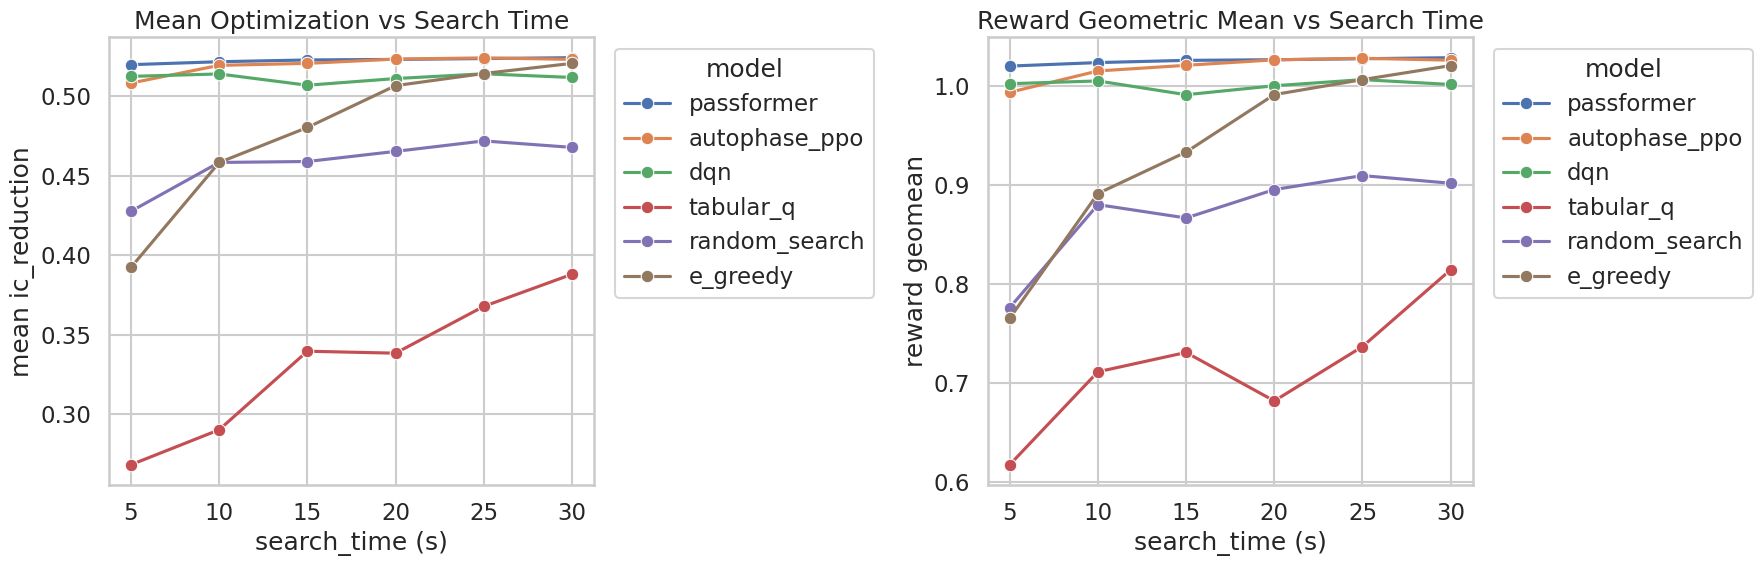

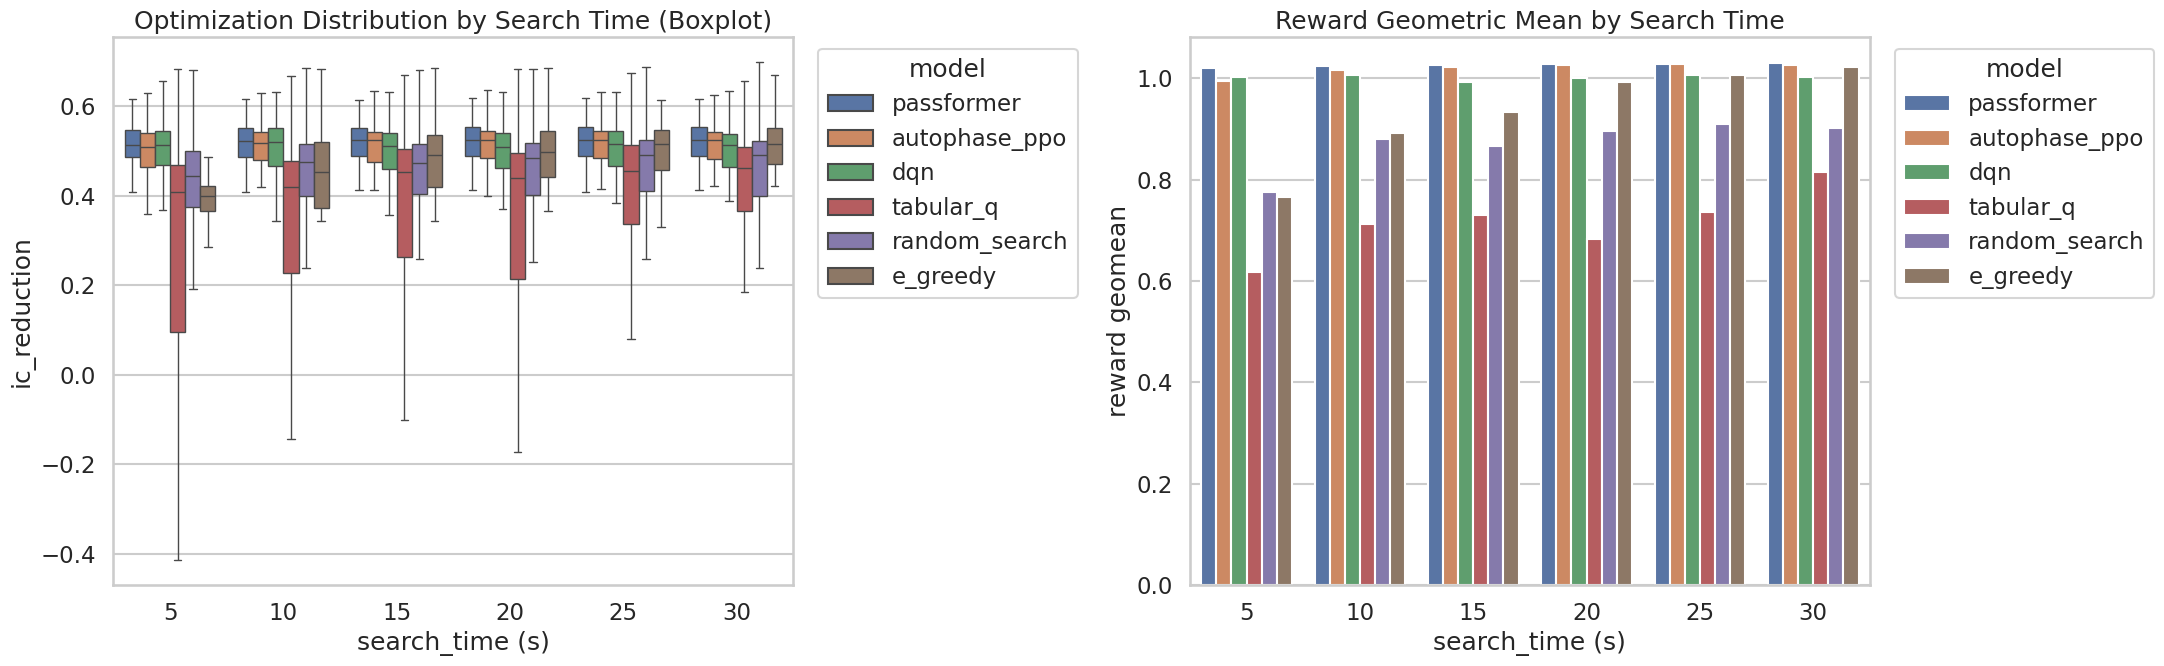

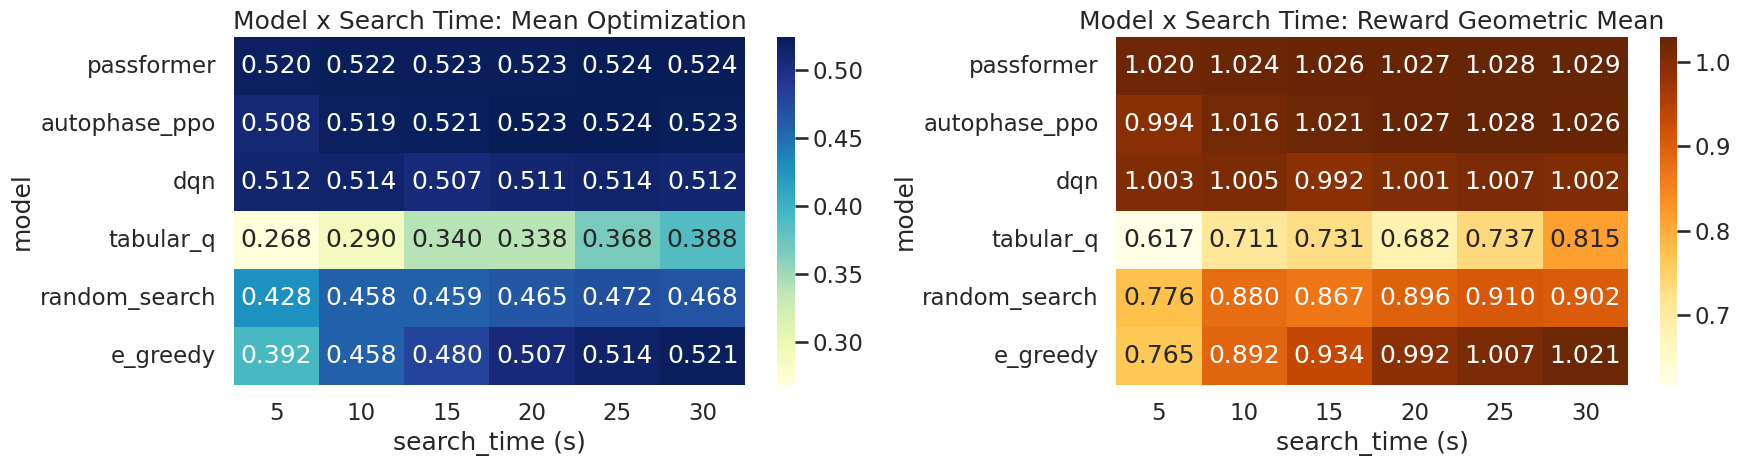

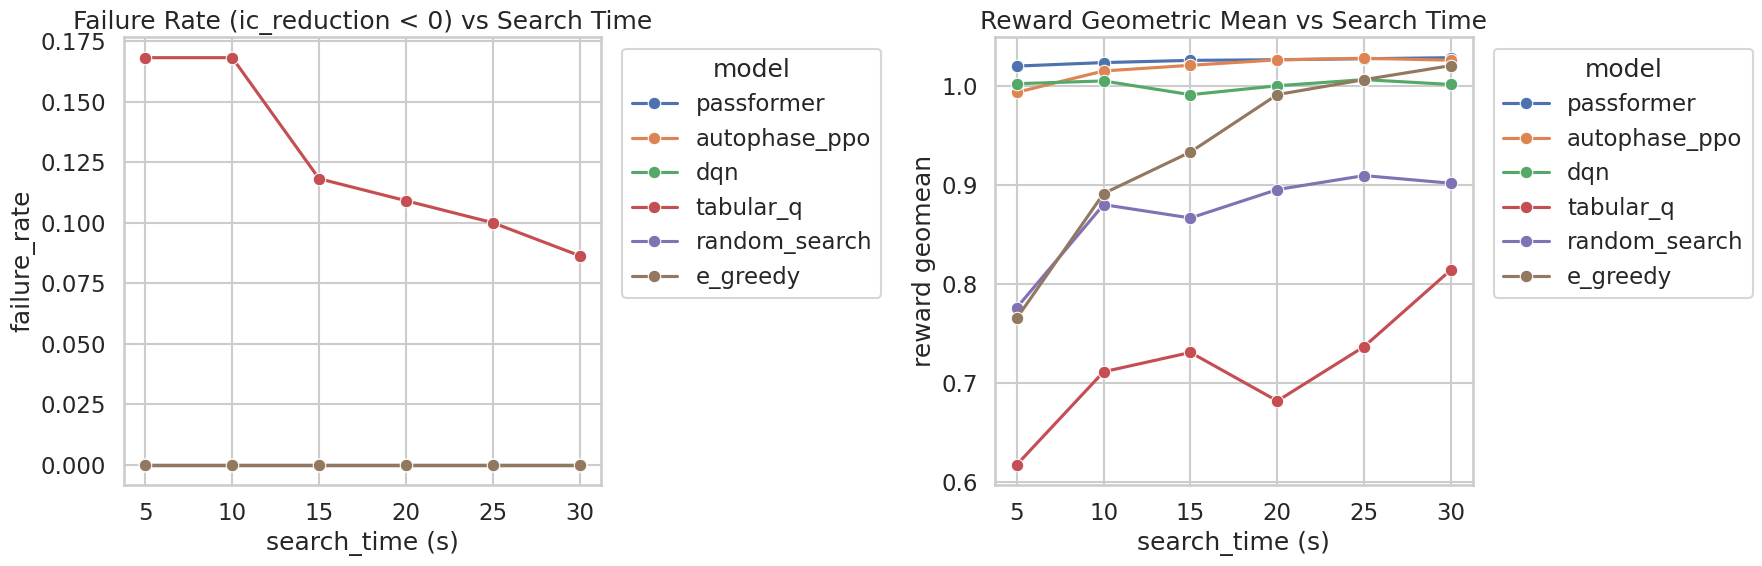

=== Recommended model by search time (ranked by mean_ic_reduction) ===


,search_time,model_name,mean_ic_reduction,reward_geomean,median_ic_reduction,failure_rate,gain_per_second,n
0,5,passformer,0.519812,1.020500,0.514586,0.0,0.077595,220
1,10,passformer,0.521659,1.024042,0.522802,0.0,0.043929,220
2,15,passformer,0.522779,1.026281,0.524091,0.0,0.030622,220
3,20,autophase_ppo,0.523333,1.026804,0.525088,0.0,0.025578,220
4,25,autophase_ppo,0.524082,1.028392,0.525925,0.0,0.020537,220
5,30,passformer,0.524206,1.028994,0.524514,0.0,0.016225,220


In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")


def safe_geomean(x):
    x = pd.Series(x).dropna()
    x = x[x > 0]
    if x.empty:
        return np.nan
    return float(np.exp(np.mean(np.log(x))))


# Keep a fixed order for stable plots
model_order = ["passformer", "autophase_ppo", "dqn", "tabular_q", "random_search", "e_greedy"]
time_order = [5, 10, 15, 20, 25, 30]

plot_df = all_models_df.copy()
plot_df = plot_df[plot_df["search_time"].isin(time_order)].copy()
plot_df["model_name"] = pd.Categorical(plot_df["model_name"], categories=model_order, ordered=True)

# Failure definition: negative optimization over O0 (change if needed)
plot_df["is_failure"] = plot_df["ic_reduction"] < 0

# Aggregated metrics: mean / median / quantiles / failure rate / average walltime / reward geomean
metrics_df = (
    plot_df.groupby(["model_name", "search_time"], observed=True)
    .agg(
        n=("ic_reduction", "size"),
        mean_ic_reduction=("ic_reduction", "mean"),
        median_ic_reduction=("ic_reduction", "median"),
        p25_ic_reduction=("ic_reduction", lambda x: x.quantile(0.25)),
        p75_ic_reduction=("ic_reduction", lambda x: x.quantile(0.75)),
        failure_rate=("is_failure", "mean"),
        mean_walltime=("walltime", "mean"),
        reward_geomean=("reward", safe_geomean),
    )
    .reset_index()
)

# Gain per second (higher is better)
metrics_df["gain_per_second"] = metrics_df["mean_ic_reduction"] / metrics_df["mean_walltime"].replace(0, np.nan)

print("=== Aggregated metrics preview ===")
display(metrics_df.head(12))

# Plot 1: mean optimization vs search time (left) + reward geomean vs search time (right)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=metrics_df,
    x="search_time",
    y="mean_ic_reduction",
    hue="model_name",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Mean Optimization vs Search Time")
axes[0].set_xlabel("search_time (s)")
axes[0].set_ylabel("mean ic_reduction")
axes[0].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.lineplot(
    data=metrics_df,
    x="search_time",
    y="reward_geomean",
    hue="model_name",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Reward Geometric Mean vs Search Time")
axes[1].set_xlabel("search_time (s)")
axes[1].set_ylabel("reward geomean")
axes[1].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Plot 2: distribution stability (left) + reward geomean bars (right)
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

sns.boxplot(
    data=plot_df,
    x="search_time",
    y="ic_reduction",
    hue="model_name",
    showfliers=False,
    ax=axes[0],
)
axes[0].set_title("Optimization Distribution by Search Time (Boxplot)")
axes[0].set_xlabel("search_time (s)")
axes[0].set_ylabel("ic_reduction")
axes[0].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.barplot(
    data=metrics_df,
    x="search_time",
    y="reward_geomean",
    hue="model_name",
    ax=axes[1],
)
axes[1].set_title("Reward Geometric Mean by Search Time")
axes[1].set_xlabel("search_time (s)")
axes[1].set_ylabel("reward geomean")
axes[1].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Plot 3: model x search time heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

heatmap_ic = metrics_df.pivot(index="model_name", columns="search_time", values="mean_ic_reduction")
heatmap_reward = metrics_df.pivot(index="model_name", columns="search_time", values="reward_geomean")

sns.heatmap(heatmap_ic, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Model x Search Time: Mean Optimization")
axes[0].set_xlabel("search_time (s)")
axes[0].set_ylabel("model")

sns.heatmap(heatmap_reward, annot=True, fmt=".3f", cmap="YlOrBr", ax=axes[1])
axes[1].set_title("Model x Search Time: Reward Geometric Mean")
axes[1].set_xlabel("search_time (s)")
axes[1].set_ylabel("model")

plt.tight_layout()
plt.show()

# Plot 4: failure rate vs search time (left) + reward geomean vs search time (right)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=metrics_df,
    x="search_time",
    y="failure_rate",
    hue="model_name",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Failure Rate (ic_reduction < 0) vs Search Time")
axes[0].set_xlabel("search_time (s)")
axes[0].set_ylabel("failure_rate")
axes[0].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.lineplot(
    data=metrics_df,
    x="search_time",
    y="reward_geomean",
    hue="model_name",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Reward Geometric Mean vs Search Time")
axes[1].set_xlabel("search_time (s)")
axes[1].set_ylabel("reward geomean")
axes[1].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Recommended model for each search time (by highest mean_ic_reduction)
best_by_time = (
    metrics_df.sort_values(["search_time", "mean_ic_reduction"], ascending=[True, False])
    .groupby("search_time", as_index=False)
    .first()
    [["search_time", "model_name", "mean_ic_reduction", "reward_geomean", "median_ic_reduction", "failure_rate", "gain_per_second", "n"]]
)

print("=== Recommended model by search time (ranked by mean_ic_reduction) ===")
display(best_by_time)


=== Pairwise summary: Passformer vs each opponent (low search time) ===


,search_time,opponent,n_pairs,win_rate,tie_rate,mean_diff_passformer_minus_opponent,median_diff_passformer_minus_opponent,reward_mean_diff_passformer_minus_opponent,reward_win_rate,mean_diff_ci95_low,mean_diff_ci95_high,wilcoxon_pvalue_greater
0,5,autophase_ppo,22,0.590909,0.0,0.012736,0.011624,0.026251,0.590909,0.003690,0.022770,1.376772e-02
1,5,dqn,22,0.500000,0.0,0.007363,0.005590,0.016101,0.500000,-0.000115,0.014649,4.920530e-02
2,5,e_greedy,22,1.000000,0.0,0.127533,0.118505,0.249507,1.000000,0.108723,0.151482,2.384186e-07
3,5,random_search,22,1.000000,0.0,0.092226,0.086711,0.186479,1.000000,0.068010,0.116038,2.384186e-07
4,5,tabular_q,22,1.000000,0.0,0.251679,0.219904,0.506521,1.000000,0.204933,0.301379,2.384186e-07
5,10,autophase_ppo,22,0.590909,0.0,0.004283,0.005370,0.009239,0.590909,-0.001896,0.010698,1.239495e-01
6,10,dqn,22,0.500000,0.0,0.007689,0.004814,0.016539,0.500000,-0.001453,0.017093,6.033874e-02
7,10,e_greedy,22,1.000000,0.0,0.063391,0.044354,0.126557,1.000000,0.044337,0.083385,2.384186e-07
8,10,random_search,22,0.954545,0.0,0.063357,0.060446,0.130815,0.954545,0.045231,0.081596,7.152557e-07
9,10,tabular_q,22,1.000000,0.0,0.231794,0.186857,0.463062,1.000000,0.174813,0.295910,2.384186e-07


=== Average rank by model and search_time (lower is better) ===


,model_name,search_time,avg_rank,avg_reward_rank
3,dqn,5,15.756818,15.781818
9,passformer,5,15.859091,15.800000
0,autophase_ppo,5,20.057870,20.076389
12,random_search,5,38.552273,38.563636
15,tabular_q,5,44.531818,44.536364
6,e_greedy,5,47.515909,47.515909
4,dqn,10,13.454545,13.436364
1,autophase_ppo,10,14.944444,14.952381
10,passformer,10,15.218182,15.270455
13,random_search,10,33.245455,33.213636


=== Overall average rank on low search times (5/10/15) ===


,model_name,avg_rank_low_time,avg_reward_rank_low_time
3,passformer,16.831818,16.820455
0,autophase_ppo,18.018036,18.004008
1,dqn,18.359848,18.343182
4,random_search,38.446970,38.440152
2,e_greedy,39.084091,39.063636
5,tabular_q,42.734446,42.800455


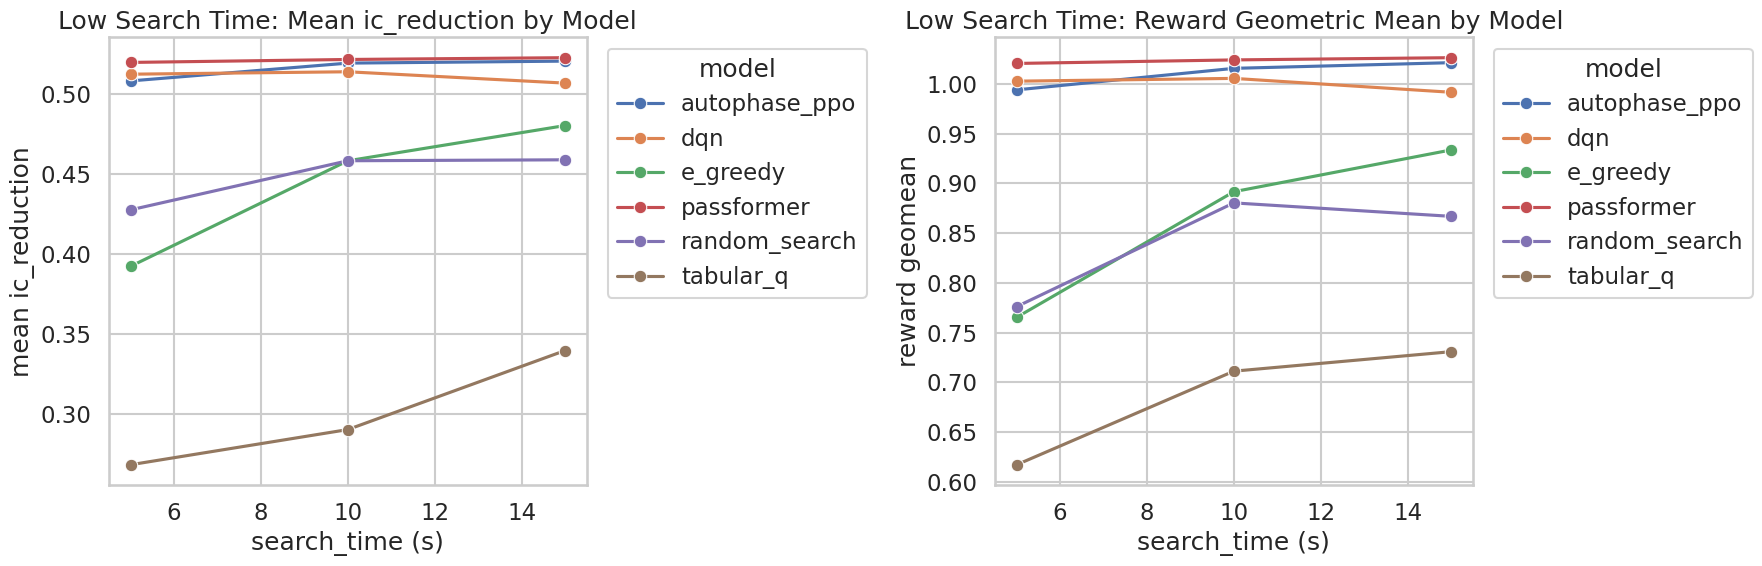

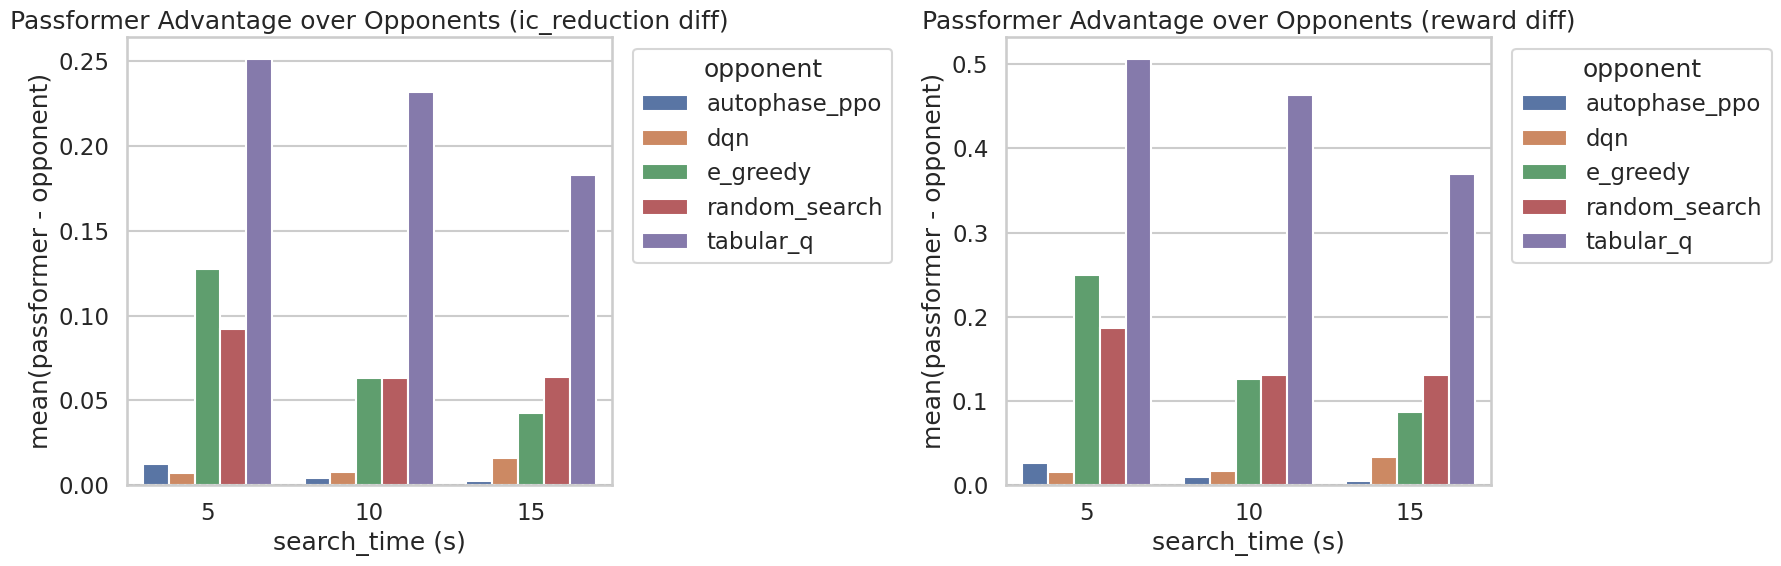

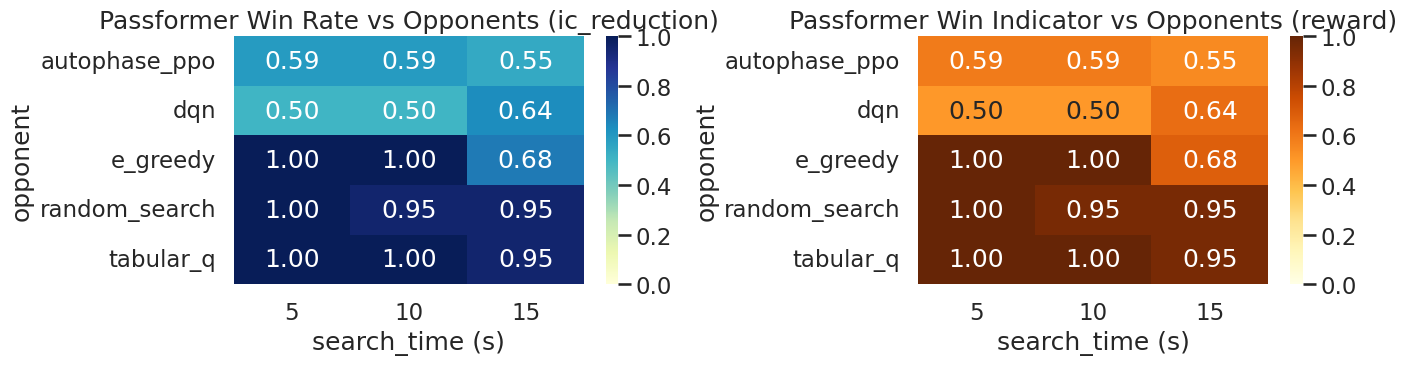

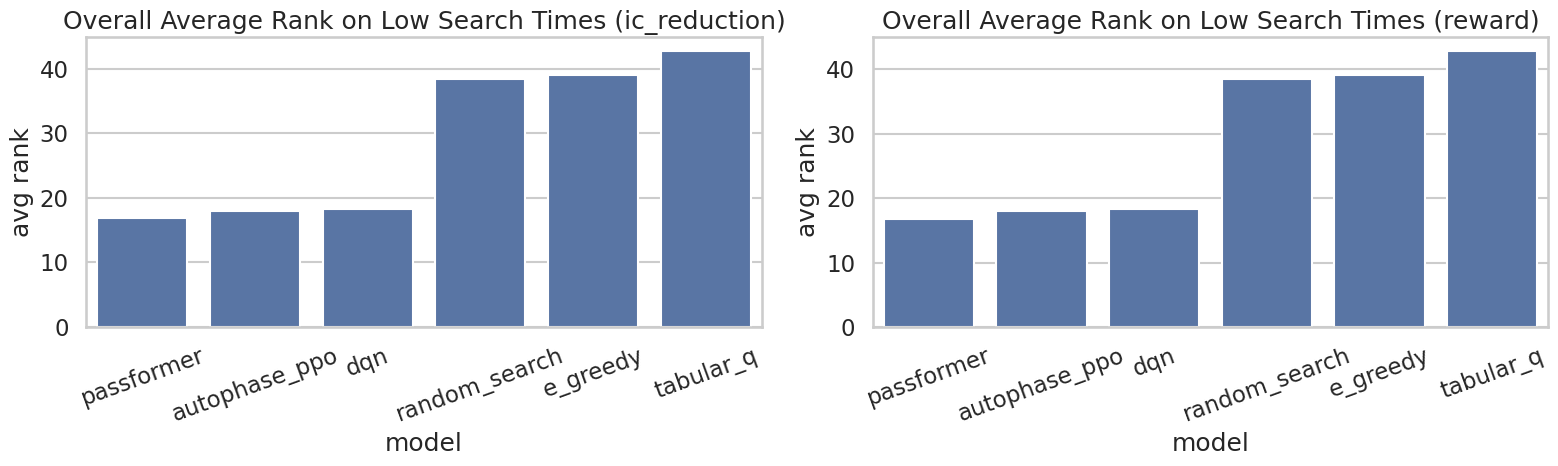

=== Reporting table: Passformer low-time advantage ===


,search_time,opponent,n_pairs,win_rate,mean_diff_passformer_minus_opponent,reward_mean_diff_passformer_minus_opponent,mean_diff_ci95_low,mean_diff_ci95_high,wilcoxon_pvalue_greater,significant_at_0_05
0,5,autophase_ppo,22,0.590909,0.012736,0.026251,0.003690,0.022770,1.376772e-02,True
1,5,dqn,22,0.500000,0.007363,0.016101,-0.000115,0.014649,4.920530e-02,True
2,5,e_greedy,22,1.000000,0.127533,0.249507,0.108723,0.151482,2.384186e-07,True
3,5,random_search,22,1.000000,0.092226,0.186479,0.068010,0.116038,2.384186e-07,True
4,5,tabular_q,22,1.000000,0.251679,0.506521,0.204933,0.301379,2.384186e-07,True
5,10,autophase_ppo,22,0.590909,0.004283,0.009239,-0.001896,0.010698,1.239495e-01,False
6,10,dqn,22,0.500000,0.007689,0.016539,-0.001453,0.017093,6.033874e-02,False
7,10,e_greedy,22,1.000000,0.063391,0.126557,0.044337,0.083385,2.384186e-07,True
8,10,random_search,22,0.954545,0.063357,0.130815,0.045231,0.081596,7.152557e-07,True
9,10,tabular_q,22,1.000000,0.231794,0.463062,0.174813,0.295910,2.384186e-07,True


In [4]:
# Passformer low-search-time advantage analysis (focus on 5s/10s/15s)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

sns.set_theme(style="whitegrid", context="talk")


def safe_geomean(x):
    x = pd.Series(x).dropna()
    x = x[x > 0]
    if x.empty:
        return np.nan
    return float(np.exp(np.mean(np.log(x))))


low_times = [5, 10, 15]
metric_col = "ic_reduction"
reward_col = "reward"
passformer_name = "passformer"

low_df = all_models_df[all_models_df["search_time"].isin(low_times)].copy()
low_df = low_df.dropna(subset=["benchmark", "model_name", "search_time", metric_col, reward_col, "walltime"])

if low_df.empty:
    raise ValueError("No low-search-time data found for 5/10/15s.")

# Pairwise comparison: Passformer vs each other model at each low search time
opponents = sorted([m for m in low_df["model_name"].unique() if m != passformer_name])
pairwise_rows = []

for t in low_times:
    t_df = low_df[low_df["search_time"] == t]
    wide_ic = t_df.pivot_table(index="benchmark", columns="model_name", values=metric_col, aggfunc="mean")
    wide_reward = t_df.pivot_table(index="benchmark", columns="model_name", values=reward_col, aggfunc="mean")

    for opp in opponents:
        if (passformer_name not in wide_ic.columns) or (opp not in wide_ic.columns):
            continue
        if (passformer_name not in wide_reward.columns) or (opp not in wide_reward.columns):
            continue

        paired_ic = wide_ic[[passformer_name, opp]].dropna()
        paired_reward = wide_reward[[passformer_name, opp]].dropna()
        if paired_ic.empty or paired_reward.empty:
            continue

        diff_ic = paired_ic[passformer_name] - paired_ic[opp]
        diff_reward = paired_reward[passformer_name] - paired_reward[opp]

        n_pairs = int(min(diff_ic.shape[0], diff_reward.shape[0]))
        win_rate = float((diff_ic > 0).mean())
        tie_rate = float((diff_ic == 0).mean())
        mean_diff = float(diff_ic.mean())
        median_diff = float(diff_ic.median())
        reward_mean_diff = float(diff_reward.mean())
        reward_win_rate = float((diff_reward > 0).mean())

        # Bootstrap CI for mean difference (ic_reduction)
        rng = np.random.default_rng(42)
        boot = rng.choice(diff_ic.to_numpy(), size=(2000, diff_ic.shape[0]), replace=True).mean(axis=1)
        ci_low, ci_high = np.quantile(boot, [0.025, 0.975])

        # One-sided Wilcoxon signed-rank test: Passformer > Opponent
        p_value = np.nan
        if SCIPY_AVAILABLE and diff_ic.shape[0] >= 10 and not np.allclose(diff_ic.to_numpy(), 0):
            try:
                p_value = float(wilcoxon(diff_ic, alternative="greater", zero_method="wilcox").pvalue)
            except Exception:
                p_value = np.nan

        pairwise_rows.append(
            {
                "search_time": t,
                "opponent": opp,
                "n_pairs": n_pairs,
                "win_rate": win_rate,
                "tie_rate": tie_rate,
                "mean_diff_passformer_minus_opponent": mean_diff,
                "median_diff_passformer_minus_opponent": median_diff,
                "reward_mean_diff_passformer_minus_opponent": reward_mean_diff,
                "reward_win_rate": reward_win_rate,
                "mean_diff_ci95_low": float(ci_low),
                "mean_diff_ci95_high": float(ci_high),
                "wilcoxon_pvalue_greater": p_value,
            }
        )

pairwise_df = pd.DataFrame(pairwise_rows).sort_values(["search_time", "opponent"])
print("=== Pairwise summary: Passformer vs each opponent (low search time) ===")
display(pairwise_df)

if not SCIPY_AVAILABLE:
    print("[INFO] scipy is not available, Wilcoxon p-values are set to NaN.")

# Ranking analysis (lower rank is better)
rank_df = low_df.copy()
rank_df["rank"] = rank_df.groupby(["search_time", "benchmark"])[metric_col].rank(ascending=False, method="average")
rank_df["reward_rank"] = rank_df.groupby(["search_time", "benchmark"])[reward_col].rank(ascending=False, method="average")

rank_summary = (
    rank_df.groupby(["model_name", "search_time"], observed=True)[["rank", "reward_rank"]]
    .mean()
    .reset_index()
    .rename(columns={"rank": "avg_rank", "reward_rank": "avg_reward_rank"})
)

overall_rank = (
    rank_df.groupby(["model_name"], observed=True)[["rank", "reward_rank"]]
    .mean()
    .reset_index()
    .rename(columns={"rank": "avg_rank_low_time", "reward_rank": "avg_reward_rank_low_time"})
    .sort_values("avg_rank_low_time")
)

print("=== Average rank by model and search_time (lower is better) ===")
display(rank_summary.sort_values(["search_time", "avg_rank"]))
print("=== Overall average rank on low search times (5/10/15) ===")
display(overall_rank)

# Plot A: Mean metric on low times (all models), with reward geomean on right
plot_mean = (
    low_df.groupby(["model_name", "search_time"], observed=True)
    .agg(
        mean_metric=(metric_col, "mean"),
        reward_geomean=(reward_col, safe_geomean),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.lineplot(data=plot_mean, x="search_time", y="mean_metric", hue="model_name", marker="o", ax=axes[0])
axes[0].set_title("Low Search Time: Mean ic_reduction by Model")
axes[0].set_xlabel("search_time (s)")
axes[0].set_ylabel("mean ic_reduction")
axes[0].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.lineplot(data=plot_mean, x="search_time", y="reward_geomean", hue="model_name", marker="o", ax=axes[1])
axes[1].set_title("Low Search Time: Reward Geometric Mean by Model")
axes[1].set_xlabel("search_time (s)")
axes[1].set_ylabel("reward geomean")
axes[1].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Plot B/C: Passformer advantage and win-rate heatmaps, reward panel on right
if not pairwise_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

    sns.barplot(
        data=pairwise_df,
        x="search_time",
        y="mean_diff_passformer_minus_opponent",
        hue="opponent",
        ax=axes[0],
    )
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Passformer Advantage over Opponents (ic_reduction diff)")
    axes[0].set_xlabel("search_time (s)")
    axes[0].set_ylabel("mean(passformer - opponent)")
    axes[0].legend(title="opponent", bbox_to_anchor=(1.02, 1), loc="upper left")

    sns.barplot(
        data=pairwise_df,
        x="search_time",
        y="reward_mean_diff_passformer_minus_opponent",
        hue="opponent",
        ax=axes[1],
    )
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Passformer Advantage over Opponents (reward diff)")
    axes[1].set_xlabel("search_time (s)")
    axes[1].set_ylabel("mean(passformer - opponent)")
    axes[1].legend(title="opponent", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    win_heatmap = pairwise_df.pivot(index="opponent", columns="search_time", values="win_rate")
    reward_win_heatmap = pairwise_df.pivot(index="opponent", columns="search_time", values="reward_win_rate")

    sns.heatmap(win_heatmap, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="YlGnBu", ax=axes[0])
    axes[0].set_title("Passformer Win Rate vs Opponents (ic_reduction)")
    axes[0].set_xlabel("search_time (s)")
    axes[0].set_ylabel("opponent")

    sns.heatmap(reward_win_heatmap, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="YlOrBr", ax=axes[1])
    axes[1].set_title("Passformer Win Indicator vs Opponents (reward)")
    axes[1].set_xlabel("search_time (s)")
    axes[1].set_ylabel("opponent")

    plt.tight_layout()
    plt.show()

# Plot D: Overall low-time average rank + reward rank
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=overall_rank, x="model_name", y="avg_rank_low_time", ax=axes[0])
axes[0].set_title("Overall Average Rank on Low Search Times (ic_reduction)")
axes[0].set_xlabel("model")
axes[0].set_ylabel("avg rank")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=overall_rank, x="model_name", y="avg_reward_rank_low_time", ax=axes[1])
axes[1].set_title("Overall Average Rank on Low Search Times (reward)")
axes[1].set_xlabel("model")
axes[1].set_ylabel("avg rank")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Quick textual conclusion table for reporting
report_table = pairwise_df.copy()
if not report_table.empty:
    report_table["significant_at_0_05"] = report_table["wilcoxon_pvalue_greater"] < 0.05
    report_table = report_table[[
        "search_time",
        "opponent",
        "n_pairs",
        "win_rate",
        "mean_diff_passformer_minus_opponent",
        "reward_mean_diff_passformer_minus_opponent",
        "mean_diff_ci95_low",
        "mean_diff_ci95_high",
        "wilcoxon_pvalue_greater",
        "significant_at_0_05",
    ]]
    print("=== Reporting table: Passformer low-time advantage ===")
    display(report_table)


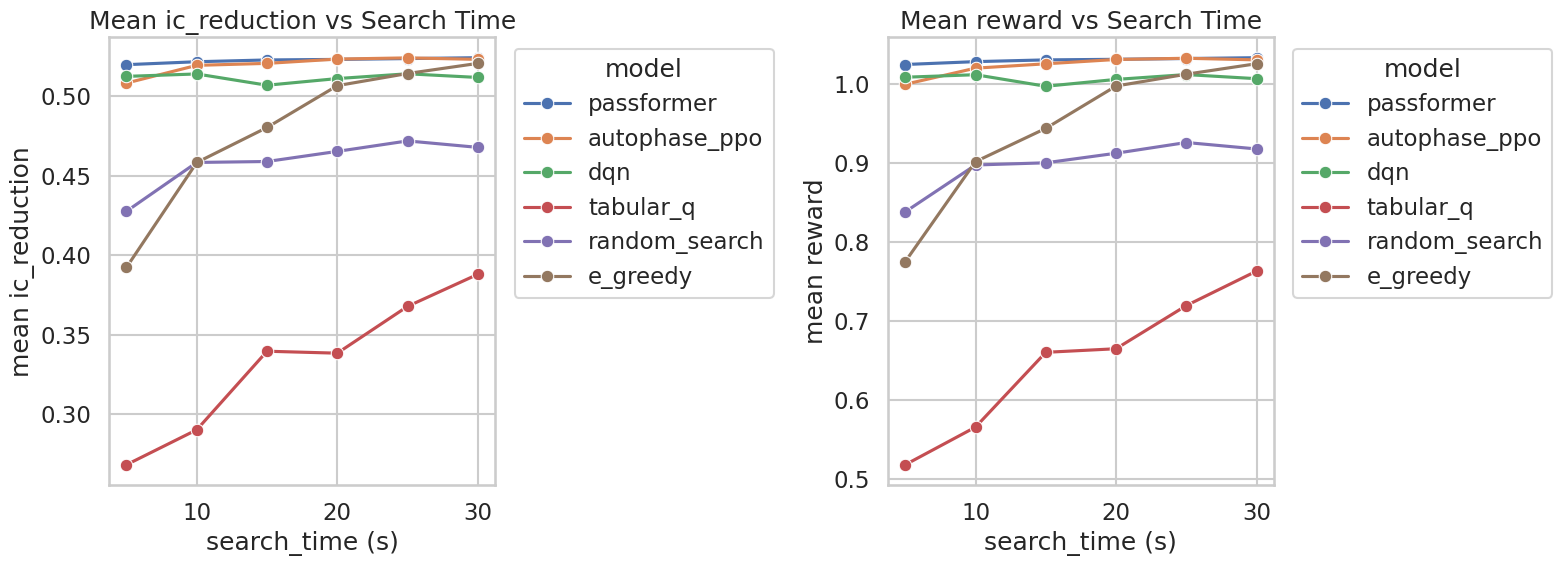

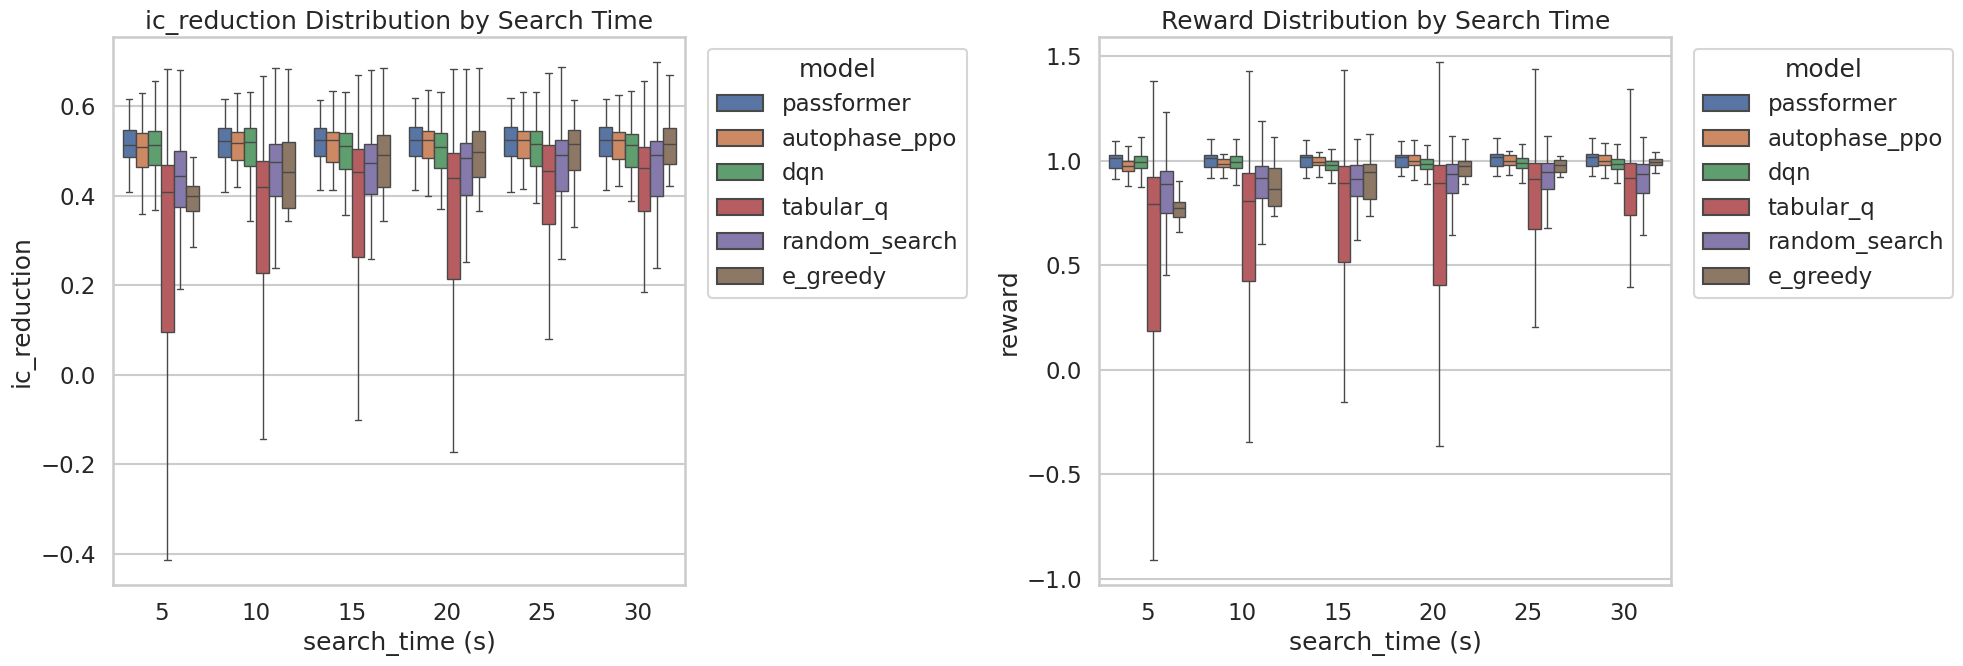

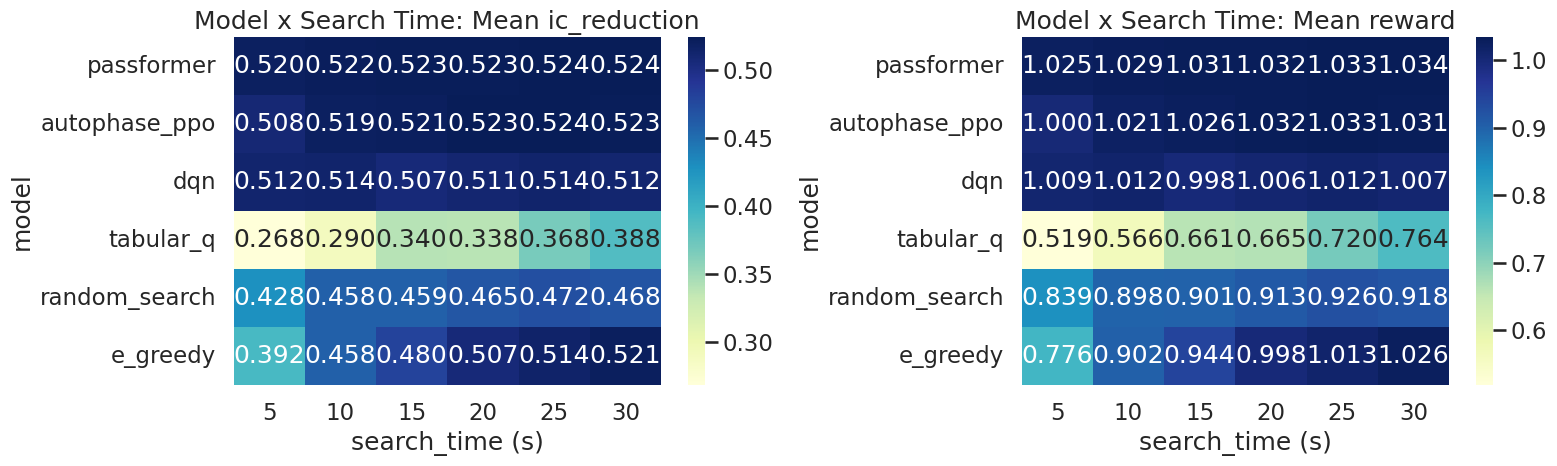

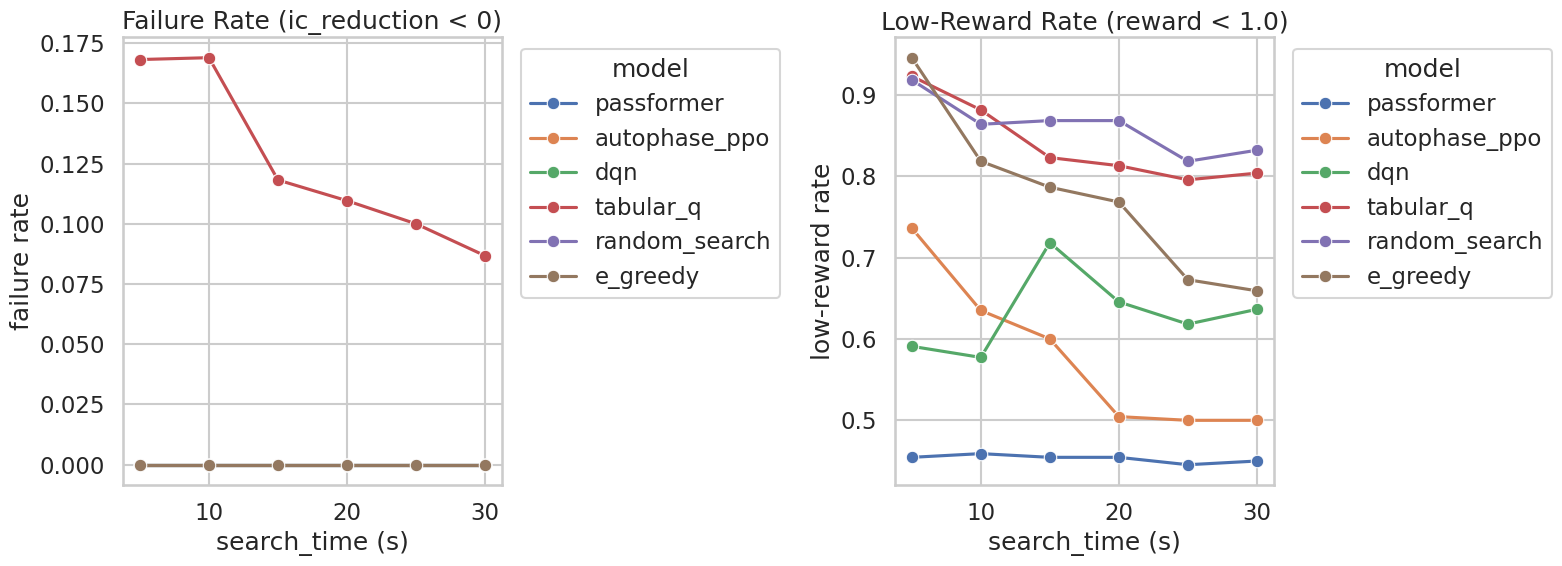

Dual-metric figure groups generated: left(ic_reduction), right(reward).


/tmp/ipykernel_775259/3651067933.py:161: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide_ic = one_t.pivot_table(index="benchmark", columns="model_name", values="ic_reduction", aggfunc="mean")
/tmp/ipykernel_775259/3651067933.py:162: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide_rw = one_t.pivot_table(index="benchmark", columns="model_name", values="reward", aggfunc="mean")
/tmp/ipykernel_775259/3651067933.py:161: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide_ic = one_t.pivot_table(index="be

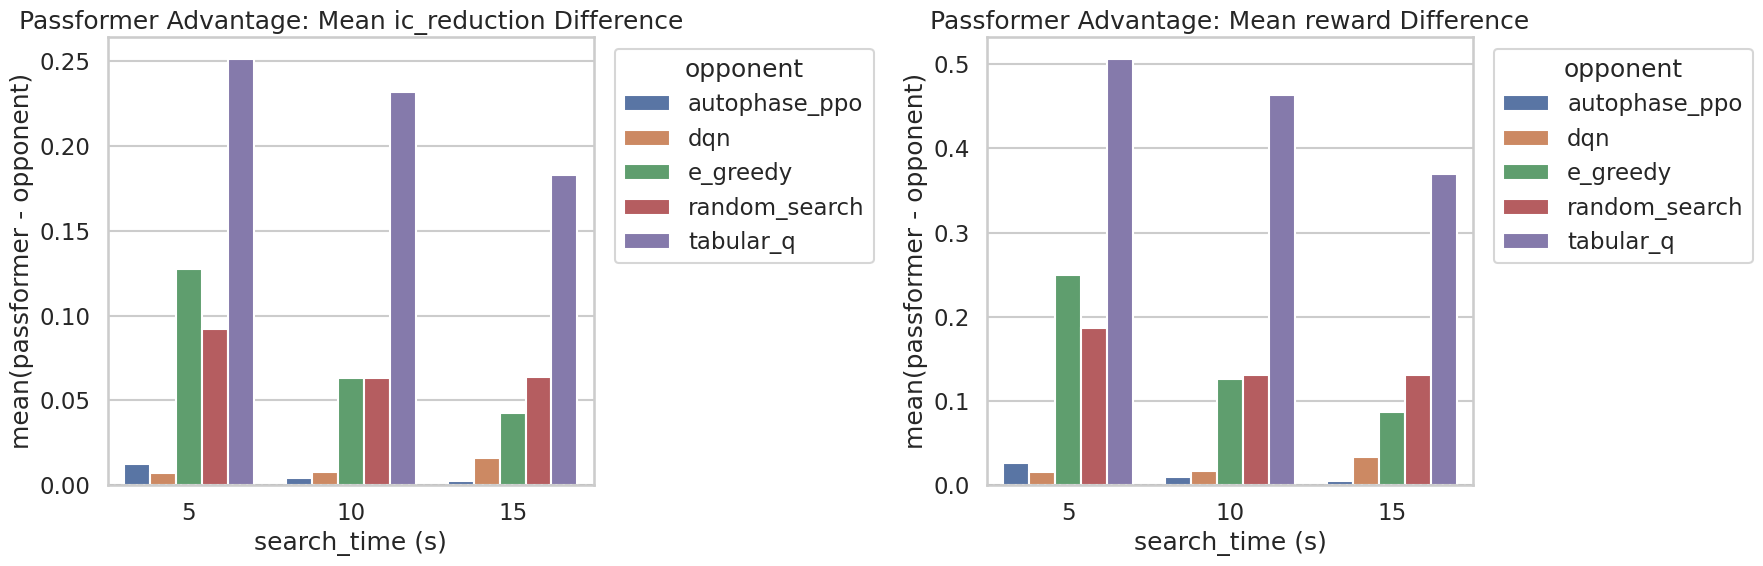

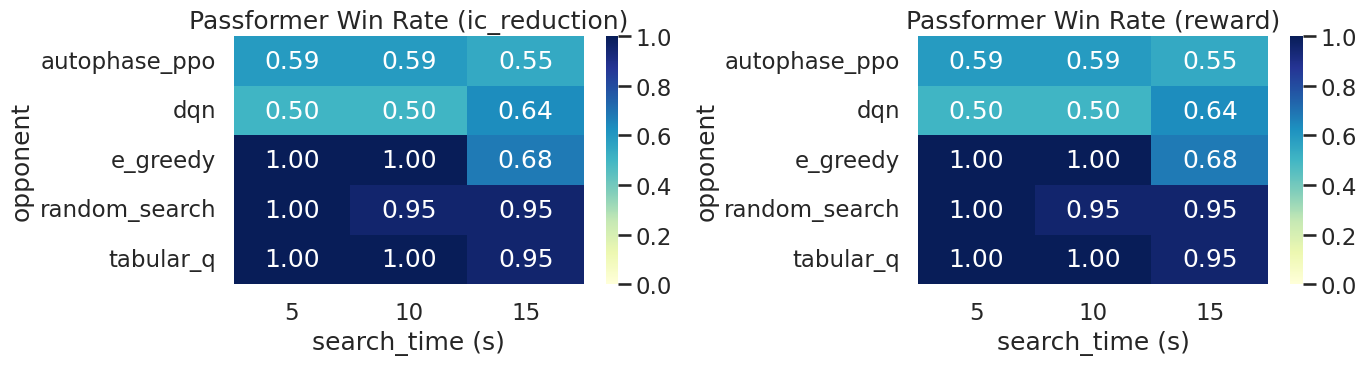

In [5]:
# Dual-metric figures: left = ic_reduction, right = reward
# This cell adds reward panels to the right side of the main figures.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

model_order = ["passformer", "autophase_ppo", "dqn", "tabular_q", "random_search", "e_greedy"]
time_order = [5, 10, 15, 20, 25, 30]
low_times = [5, 10, 15]

plot_df = all_models_df.copy()
plot_df = plot_df[plot_df["search_time"].isin(time_order)].copy()
plot_df = plot_df.dropna(subset=["model_name", "search_time", "benchmark", "ic_reduction", "reward", "walltime"])
plot_df["model_name"] = pd.Categorical(plot_df["model_name"], categories=model_order, ordered=True)

# Optional risk definition for reward: reward < 1.0
# You can change this threshold if your reward has a different interpretation.
reward_threshold = 1.0
plot_df["is_failure_ic"] = plot_df["ic_reduction"] < 0
plot_df["is_low_reward"] = plot_df["reward"] < reward_threshold

metrics2_df = (
    plot_df.groupby(["model_name", "search_time"], observed=True)
    .agg(
        n=("ic_reduction", "size"),
        mean_ic_reduction=("ic_reduction", "mean"),
        mean_reward=("reward", "mean"),
        failure_rate_ic=("is_failure_ic", "mean"),
        low_reward_rate=("is_low_reward", "mean"),
    )
    .reset_index()
)

# ===== Figure Group 1: trend lines =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

sns.lineplot(
    data=metrics2_df,
    x="search_time",
    y="mean_ic_reduction",
    hue="model_name",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Mean ic_reduction vs Search Time")
axes[0].set_xlabel("search_time (s)")
axes[0].set_ylabel("mean ic_reduction")
axes[0].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.lineplot(
    data=metrics2_df,
    x="search_time",
    y="mean_reward",
    hue="model_name",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Mean reward vs Search Time")
axes[1].set_xlabel("search_time (s)")
axes[1].set_ylabel("mean reward")
axes[1].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# ===== Figure Group 2: distribution boxplots =====
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharex=True)

sns.boxplot(
    data=plot_df,
    x="search_time",
    y="ic_reduction",
    hue="model_name",
    showfliers=False,
    ax=axes[0],
)
axes[0].set_title("ic_reduction Distribution by Search Time")
axes[0].set_xlabel("search_time (s)")
axes[0].set_ylabel("ic_reduction")
axes[0].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.boxplot(
    data=plot_df,
    x="search_time",
    y="reward",
    hue="model_name",
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("Reward Distribution by Search Time")
axes[1].set_xlabel("search_time (s)")
axes[1].set_ylabel("reward")
axes[1].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# ===== Figure Group 3: heatmaps =====
heat_ic = metrics2_df.pivot(index="model_name", columns="search_time", values="mean_ic_reduction")
heat_rw = metrics2_df.pivot(index="model_name", columns="search_time", values="mean_reward")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(heat_ic, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Model x Search Time: Mean ic_reduction")
axes[0].set_xlabel("search_time (s)")
axes[0].set_ylabel("model")

sns.heatmap(heat_rw, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Model x Search Time: Mean reward")
axes[1].set_xlabel("search_time (s)")
axes[1].set_ylabel("model")

plt.tight_layout()
plt.show()

# ===== Figure Group 4: risk curves =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

sns.lineplot(
    data=metrics2_df,
    x="search_time",
    y="failure_rate_ic",
    hue="model_name",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Failure Rate (ic_reduction < 0)")
axes[0].set_xlabel("search_time (s)")
axes[0].set_ylabel("failure rate")
axes[0].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.lineplot(
    data=metrics2_df,
    x="search_time",
    y="low_reward_rate",
    hue="model_name",
    marker="o",
    ax=axes[1],
)
axes[1].set_title(f"Low-Reward Rate (reward < {reward_threshold})")
axes[1].set_xlabel("search_time (s)")
axes[1].set_ylabel("low-reward rate")
axes[1].legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

print("Dual-metric figure groups generated: left(ic_reduction), right(reward).")

# ===== Low-time Passformer-focused dual panels =====
low_df = plot_df[plot_df["search_time"].isin(low_times)].copy()

# Passformer pairwise diff for both metrics
opponents = sorted([m for m in low_df["model_name"].dropna().unique() if m != "passformer"])
pair_rows = []
for t in low_times:
    one_t = low_df[low_df["search_time"] == t]
    wide_ic = one_t.pivot_table(index="benchmark", columns="model_name", values="ic_reduction", aggfunc="mean")
    wide_rw = one_t.pivot_table(index="benchmark", columns="model_name", values="reward", aggfunc="mean")

    for opp in opponents:
        if "passformer" not in wide_ic.columns or opp not in wide_ic.columns:
            continue
        if "passformer" not in wide_rw.columns or opp not in wide_rw.columns:
            continue

        d_ic = (wide_ic["passformer"] - wide_ic[opp]).dropna()
        d_rw = (wide_rw["passformer"] - wide_rw[opp]).dropna()
        if d_ic.empty or d_rw.empty:
            continue

        pair_rows.append(
            {
                "search_time": t,
                "opponent": opp,
                "mean_diff_ic": float(d_ic.mean()),
                "mean_diff_reward": float(d_rw.mean()),
                "win_rate_ic": float((d_ic > 0).mean()),
                "win_rate_reward": float((d_rw > 0).mean()),
            }
        )

pair_dual_df = pd.DataFrame(pair_rows)

if not pair_dual_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

    sns.barplot(data=pair_dual_df, x="search_time", y="mean_diff_ic", hue="opponent", ax=axes[0])
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Passformer Advantage: Mean ic_reduction Difference")
    axes[0].set_xlabel("search_time (s)")
    axes[0].set_ylabel("mean(passformer - opponent)")
    axes[0].legend(title="opponent", bbox_to_anchor=(1.02, 1), loc="upper left")

    sns.barplot(data=pair_dual_df, x="search_time", y="mean_diff_reward", hue="opponent", ax=axes[1])
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Passformer Advantage: Mean reward Difference")
    axes[1].set_xlabel("search_time (s)")
    axes[1].set_ylabel("mean(passformer - opponent)")
    axes[1].legend(title="opponent", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

    win_ic = pair_dual_df.pivot(index="opponent", columns="search_time", values="win_rate_ic")
    win_rw = pair_dual_df.pivot(index="opponent", columns="search_time", values="win_rate_reward")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.heatmap(win_ic, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="YlGnBu", ax=axes[0])
    axes[0].set_title("Passformer Win Rate (ic_reduction)")
    axes[0].set_xlabel("search_time (s)")
    axes[0].set_ylabel("opponent")

    sns.heatmap(win_rw, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="YlGnBu", ax=axes[1])
    axes[1].set_title("Passformer Win Rate (reward)")
    axes[1].set_xlabel("search_time (s)")
    axes[1].set_ylabel("opponent")

    plt.tight_layout()
    plt.show()


In [7]:
# Paper-ready tables (main text): Table 1/2/3 + LaTeX export
import numpy as np
import pandas as pd


def safe_geomean(x):
    x = pd.Series(x).dropna()
    x = x[x > 0]
    if x.empty:
        return np.nan
    return float(np.exp(np.mean(np.log(x))))


# ---------- Common setup ----------
model_order = ["passformer", "autophase_ppo", "dqn", "tabular_q", "random_search", "e_greedy"]
time_order = [5, 10, 15, 20, 25, 30]
low_times = [5, 10, 15]

paper_df = all_models_df.copy()
paper_df = paper_df[paper_df["search_time"].isin(time_order)].copy()
paper_df = paper_df.dropna(subset=["model_name", "search_time", "benchmark", "ic_reduction", "reward", "walltime"])
paper_df["model_name"] = pd.Categorical(paper_df["model_name"], categories=model_order, ordered=True)
paper_df["is_failure"] = paper_df["ic_reduction"] < 0

# ---------- Table 1: Main comparison across models and times ----------
table1 = (
    paper_df.groupby(["model_name", "search_time"], observed=True)
    .agg(
        n=("ic_reduction", "size"),
        ic_mean=("ic_reduction", "mean"),
        ic_median=("ic_reduction", "median"),
        reward_geomean=("reward", safe_geomean),
        failure_rate=("is_failure", "mean"),
    )
    .reset_index()
    .sort_values(["search_time", "model_name"])
)

# format for paper display
table1_show = table1.copy()
for c in ["ic_mean", "ic_median", "reward_geomean", "failure_rate"]:
    table1_show[c] = table1_show[c].map(lambda v: round(float(v), 4))

print("=== Table 1: Main comparison across models and search times ===")
display(table1_show)

# ---------- Table 2: Passformer vs O3/Oz by search time ----------
passformer_df = paper_df[paper_df["model_name"] == "passformer"].copy()
passformer_df = passformer_df.dropna(subset=["ic_reduction_policy_vs_o3", "ic_reduction_policy_vs_oz"])


table2 = (
    passformer_df.groupby("search_time")
    .agg(
        n=("benchmark", "size"),
        reward_geomean=("reward", safe_geomean),
        policy_vs_o3_mean=("ic_reduction_policy_vs_o3", "mean"),
        policy_vs_o3_median=("ic_reduction_policy_vs_o3", "median"),
        policy_vs_o3_win_rate=("ic_reduction_policy_vs_o3", lambda x: (x > 0).mean()),
        policy_vs_oz_mean=("ic_reduction_policy_vs_oz", "mean"),
        policy_vs_oz_median=("ic_reduction_policy_vs_oz", "median"),
        policy_vs_oz_win_rate=("ic_reduction_policy_vs_oz", lambda x: (x > 0).mean()),
    )
    .reset_index()
    .sort_values("search_time")
)

table2_show = table2.copy()
for c in [
    "reward_geomean",
    "policy_vs_o3_mean",
    "policy_vs_o3_median",
    "policy_vs_o3_win_rate",
    "policy_vs_oz_mean",
    "policy_vs_oz_median",
    "policy_vs_oz_win_rate",
]:
    table2_show[c] = table2_show[c].map(lambda v: round(float(v), 4))

print("=== Table 2: Passformer vs O3/Oz by search time ===")
display(table2_show)

# ---------- Table 3: Low-budget summary (5/10/15s) ----------
low_df = paper_df[paper_df["search_time"].isin(low_times)].copy()

# ranking by ic_reduction (larger is better => lower rank is better)
rank_df = low_df.copy()
rank_df["rank"] = rank_df.groupby(["search_time", "benchmark"])["ic_reduction"].rank(ascending=False, method="average")

rank_summary = (
    rank_df.groupby("model_name", observed=True)["rank"]
    .mean()
    .reset_index(name="avg_rank_low_time")
)

# passformer win-rate vs opponents on low times
opponents = sorted([m for m in low_df["model_name"].dropna().unique() if m != "passformer"])
win_rows = []
for t in low_times:
    one_t = low_df[low_df["search_time"] == t]
    wide = one_t.pivot_table(index="benchmark", columns="model_name", values="ic_reduction", aggfunc="mean")
    for opp in opponents:
        if "passformer" not in wide.columns or opp not in wide.columns:
            continue
        diff = (wide["passformer"] - wide[opp]).dropna()
        if diff.empty:
            continue
        win_rows.append(
            {
                "search_time": t,
                "opponent": opp,
                "passformer_win_rate": float((diff > 0).mean()),
                "passformer_mean_diff": float(diff.mean()),
            }
        )
win_df = pd.DataFrame(win_rows)

# passformer low-time overall row
passformer_low = low_df[low_df["model_name"] == "passformer"].copy()
passformer_low_summary = pd.DataFrame(
    {
        "model_name": ["passformer"],
        "n_low_time": [int(len(passformer_low))],
        "reward_geomean_low_time": [safe_geomean(passformer_low["reward"])],
        "ic_mean_low_time": [float(passformer_low["ic_reduction"].mean())],
        "ic_median_low_time": [float(passformer_low["ic_reduction"].median())],
        "avg_rank_low_time": [
            float(rank_summary.loc[rank_summary["model_name"] == "passformer", "avg_rank_low_time"].iloc[0])
            if (rank_summary["model_name"] == "passformer").any()
            else np.nan
        ],
    }
)

# merged low-time table for paper
table3 = passformer_low_summary.copy()
if not win_df.empty:
    win_pivot = win_df.pivot(index="search_time", columns="opponent", values="passformer_win_rate")
    win_pivot.columns = [f"win_rate_vs_{c}" for c in win_pivot.columns]
    win_pivot = win_pivot.reset_index()

    # add an average row over low times
    avg_row = {"search_time": "avg_5_10_15"}
    for col in [c for c in win_pivot.columns if c != "search_time"]:
        avg_row[col] = float(win_pivot[col].mean())
    win_pivot = pd.concat([win_pivot, pd.DataFrame([avg_row])], ignore_index=True)
else:
    win_pivot = pd.DataFrame()

# pretty display versions
table3_show = table3.copy()
for c in ["reward_geomean_low_time", "ic_mean_low_time", "ic_median_low_time", "avg_rank_low_time"]:
    table3_show[c] = table3_show[c].map(lambda v: round(float(v), 4))

win_pivot_show = win_pivot.copy()
for c in [col for col in win_pivot_show.columns if col != "search_time"]:
    win_pivot_show[c] = win_pivot_show[c].map(lambda v: round(float(v), 4))

print("=== Table 3a: Low-budget summary (Passformer) ===")
display(table3_show)
print("=== Table 3b: Passformer win-rate vs opponents at 5/10/15s ===")
display(win_pivot_show)

# ---------- LaTeX export strings ----------
# You can copy these directly into paper tables.
latex_table1 = table1_show.to_latex(index=False, float_format="%.4f")
latex_table2 = table2_show.to_latex(index=False, float_format="%.4f")
latex_table3a = table3_show.to_latex(index=False, float_format="%.4f")
latex_table3b = win_pivot_show.to_latex(index=False, float_format="%.4f")

print("=== LaTeX: table1 ===")
print(latex_table1)
print("=== LaTeX: table2 ===")
print(latex_table2)
print("=== LaTeX: table3a ===")
print(latex_table3a)
print("=== LaTeX: table3b ===")
print(latex_table3b)


=== Table 1: Main comparison across models and search times ===


,model_name,search_time,n,ic_mean,ic_median,reward_geomean,failure_rate
0,passformer,5,220,0.5198,0.5146,1.0205,0.0000
6,autophase_ppo,5,216,0.5082,0.5104,0.9939,0.0000
12,dqn,5,220,0.5124,0.5135,1.0027,0.0000
18,tabular_q,5,220,0.2681,0.4089,0.6173,0.1682
24,random_search,5,220,0.4276,0.4451,0.7762,0.0000
30,e_greedy,5,220,0.3923,0.3991,0.7655,0.0000
1,passformer,10,220,0.5217,0.5228,1.0240,0.0000
7,autophase_ppo,10,63,0.5194,0.5181,1.0156,0.0000
13,dqn,10,220,0.5140,0.5207,1.0055,0.0000
19,tabular_q,10,219,0.2901,0.4191,0.7113,0.1689


=== Table 2: Passformer vs O3/Oz by search time ===


,search_time,n,reward_geomean,policy_vs_o3_mean,policy_vs_o3_median,policy_vs_o3_win_rate,policy_vs_oz_mean,policy_vs_oz_median,policy_vs_oz_win_rate
0,5,220,1.0205,0.2618,0.2517,0.9818,0.0097,0.0125,0.5455
1,10,220,1.0240,0.2646,0.2558,0.9955,0.0137,0.0133,0.5409
2,15,220,1.0263,0.2664,0.2588,0.9909,0.0160,0.0171,0.5455
3,20,220,1.0269,0.2670,0.2599,0.9955,0.0167,0.0192,0.5455
4,25,220,1.0279,0.2677,0.2613,0.9955,0.0178,0.0170,0.5500
5,30,220,1.0290,0.2686,0.2632,0.9955,0.0191,0.0201,0.5500


=== Table 3a: Low-budget summary (Passformer) ===


/tmp/ipykernel_775259/1206700984.py:101: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = one_t.pivot_table(index="benchmark", columns="model_name", values="ic_reduction", aggfunc="mean")
/tmp/ipykernel_775259/1206700984.py:101: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = one_t.pivot_table(index="benchmark", columns="model_name", values="ic_reduction", aggfunc="mean")
/tmp/ipykernel_775259/1206700984.py:101: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = one_t.pivot_table(index="bench

,model_name,n_low_time,reward_geomean_low_time,ic_mean_low_time,ic_median_low_time,avg_rank_low_time
0,passformer,660,1.0236,0.5214,0.522,16.8318


=== Table 3b: Passformer win-rate vs opponents at 5/10/15s ===


,search_time,win_rate_vs_autophase_ppo,win_rate_vs_dqn,win_rate_vs_e_greedy,win_rate_vs_random_search,win_rate_vs_tabular_q
0,5,0.5909,0.5000,1.0000,1.0000,1.0000
1,10,0.5909,0.5000,1.0000,0.9545,1.0000
2,15,0.5455,0.6364,0.6818,0.9545,0.9545
3,avg_5_10_15,0.5758,0.5455,0.8939,0.9697,0.9848


=== LaTeX: table1 ===
\begin{tabular}{lrrrrrr}
\toprule
model_name & search_time & n & ic_mean & ic_median & reward_geomean & failure_rate \\
\midrule
passformer & 5 & 220 & 0.5198 & 0.5146 & 1.0205 & 0.0000 \\
autophase_ppo & 5 & 216 & 0.5082 & 0.5104 & 0.9939 & 0.0000 \\
dqn & 5 & 220 & 0.5124 & 0.5135 & 1.0027 & 0.0000 \\
tabular_q & 5 & 220 & 0.2681 & 0.4089 & 0.6173 & 0.1682 \\
random_search & 5 & 220 & 0.4276 & 0.4451 & 0.7762 & 0.0000 \\
e_greedy & 5 & 220 & 0.3923 & 0.3991 & 0.7655 & 0.0000 \\
passformer & 10 & 220 & 0.5217 & 0.5228 & 1.0240 & 0.0000 \\
autophase_ppo & 10 & 63 & 0.5194 & 0.5181 & 1.0156 & 0.0000 \\
dqn & 10 & 220 & 0.5140 & 0.5207 & 1.0055 & 0.0000 \\
tabular_q & 10 & 219 & 0.2901 & 0.4191 & 0.7113 & 0.1689 \\
random_search & 10 & 220 & 0.4583 & 0.4747 & 0.8804 & 0.0000 \\
e_greedy & 10 & 220 & 0.4583 & 0.4524 & 0.8916 & 0.0000 \\
passformer & 15 & 220 & 0.5228 & 0.5241 & 1.0263 & 0.0000 \\
autophase_ppo & 15 & 220 & 0.5206 & 0.5248 & 1.0213 & 0.0000 \\
dqn & 1

In [9]:
# Table: rows=model (including o3/oz), columns=search_time, value=ir_reduction
import pandas as pd

search_times = [5, 10, 15, 20, 25, 30]

base_df = all_models_df[all_models_df["search_time"].isin(search_times)].copy()
base_df = base_df.dropna(subset=["model_name", "search_time", "ic_reduction"])

# Policy models (from model outputs)
policy_part = (
    base_df.groupby(["model_name", "search_time"], observed=True)["ic_reduction"]
    .mean()
    .reset_index()
    .rename(columns={"model_name": "model", "ic_reduction": "ir_reduction"})
)

# Baselines O3/Oz (taken from passformer rows)
# ic_reduction_o3_vs_o0 and ic_reduction_oz_vs_o0 are direct baseline reductions.
passformer_df = base_df[base_df["model_name"] == "passformer"].copy()
passformer_df = passformer_df.dropna(subset=["ic_reduction_o3_vs_o0", "ic_reduction_oz_vs_o0"])

o3_part = (
    passformer_df.groupby("search_time")["ic_reduction_o3_vs_o0"]
    .mean()
    .reset_index()
    .assign(model="o3")
    .rename(columns={"ic_reduction_o3_vs_o0": "ir_reduction"})
)

oz_part = (
    passformer_df.groupby("search_time")["ic_reduction_oz_vs_o0"]
    .mean()
    .reset_index()
    .assign(model="oz")
    .rename(columns={"ic_reduction_oz_vs_o0": "ir_reduction"})
)

all_part = pd.concat([policy_part, o3_part, oz_part], ignore_index=True)

ir_reduction_table = (
    all_part.pivot(index="model", columns="search_time", values="ir_reduction")
    .reindex(columns=search_times)
)

# Sort models by 5s result in descending order
if 5 in ir_reduction_table.columns:
    ir_reduction_table = ir_reduction_table.sort_values(by=5, ascending=False)

print("=== IR Reduction Table (model x search_time) ===")
display(ir_reduction_table.round(4))

# Optional LaTeX export
latex_ir_reduction_table = ir_reduction_table.round(4).to_latex(index=True, float_format="%.4f")
print("=== LaTeX: ir_reduction_table ===")
print(latex_ir_reduction_table)


=== IR Reduction Table (model x search_time) ===


search_time,5,10,15,20,25,30
model,,,,,,
passformer,0.5198,0.5217,0.5228,0.5231,0.5236,0.5242
dqn,0.5124,0.5140,0.5069,0.5111,0.5141,0.5118
oz,0.5112,0.5112,0.5112,0.5112,0.5112,0.5112
autophase_ppo,0.5082,0.5194,0.5206,0.5233,0.5241,0.5231
random_search,0.4276,0.4583,0.4589,0.4653,0.4718,0.4678
e_greedy,0.3923,0.4583,0.4803,0.5066,0.5143,0.5206
o3,0.2928,0.2928,0.2928,0.2928,0.2928,0.2928
tabular_q,0.2681,0.2901,0.3395,0.3383,0.3677,0.3879


=== LaTeX: ir_reduction_table ===
\begin{tabular}{lrrrrrr}
\toprule
search_time & 5 & 10 & 15 & 20 & 25 & 30 \\
model &  &  &  &  &  &  \\
\midrule
passformer & 0.5198 & 0.5217 & 0.5228 & 0.5231 & 0.5236 & 0.5242 \\
dqn & 0.5124 & 0.5140 & 0.5069 & 0.5111 & 0.5141 & 0.5118 \\
oz & 0.5112 & 0.5112 & 0.5112 & 0.5112 & 0.5112 & 0.5112 \\
autophase_ppo & 0.5082 & 0.5194 & 0.5206 & 0.5233 & 0.5241 & 0.5231 \\
random_search & 0.4276 & 0.4583 & 0.4589 & 0.4653 & 0.4718 & 0.4678 \\
e_greedy & 0.3923 & 0.4583 & 0.4803 & 0.5066 & 0.5143 & 0.5206 \\
o3 & 0.2928 & 0.2928 & 0.2928 & 0.2928 & 0.2928 & 0.2928 \\
tabular_q & 0.2681 & 0.2901 & 0.3395 & 0.3383 & 0.3677 & 0.3879 \\
\bottomrule
\end{tabular}

